In [ ]:
!pip install -q grad-cam torchmetrics matplotlib seaborn scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 49.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 64.9 MB/s eta 0:00:00


In [ ]:
import torch
print('GPU available:', torch.cuda.is_available())
print('Device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

GPU available: True
Device: Tesla T4


In [ ]:
import os

KAGGLE_TOKEN = "KGAT_0daa715ad5d4f26698d61960e226084b"

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/access_token', 'w') as f:
    f.write(KAGGLE_TOKEN)
os.chmod('/root/.kaggle/access_token', 0o600)

os.environ['KAGGLE_API_TOKEN'] = KAGGLE_TOKEN
print('Kaggle token saved.')

Kaggle token saved.


In [ ]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p /content/data --unzip

import os
base = '/content/data/chest_xray'
for split in ['train', 'val', 'test']:
    for cls in ['NORMAL', 'PNEUMONIA']:
        path = os.path.join(base, split, cls)
        if os.path.exists(path):
            print(f'{split}/{cls}: {len(os.listdir(path))} images')

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:25<00:00, 98.3MB/s]

train/NORMAL: 1341 images
train/PNEUMONIA: 3875 images
val/NORMAL: 8 images
val/PNEUMONIA: 8 images
test/NORMAL: 234 images
test/PNEUMONIA: 390 images


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
SAVE_DIR = '/content/drive/MyDrive/pulmonary_model'
os.makedirs(SAVE_DIR, exist_ok=True)
print('Save directory:', SAVE_DIR)

Mounted at /content/drive
Save directory: /content/drive/MyDrive/pulmonary_model


In [ ]:
import torch
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np

IMG_SIZE   = 224
BATCH_SIZE = 32
NUM_WORKERS = 2

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 20, IMG_SIZE + 20)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

train_dataset = ImageFolder(os.path.join(base, 'train'), transform=train_transform)
val_dataset   = ImageFolder(os.path.join(base, 'val'),   transform=val_transform)
test_dataset  = ImageFolder(os.path.join(base, 'test'),  transform=val_transform)

class_counts = np.array([len(os.listdir(os.path.join(base, 'train', c)))
                         for c in train_dataset.classes])
class_weights = 1.0 / class_counts
sample_weights = [class_weights[label] for _, label in train_dataset.samples]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print('Classes:', train_dataset.classes)
print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')


Classes: ['NORMAL', 'PNEUMONIA']
Train: 5216 | Val: 16 | Test: 624


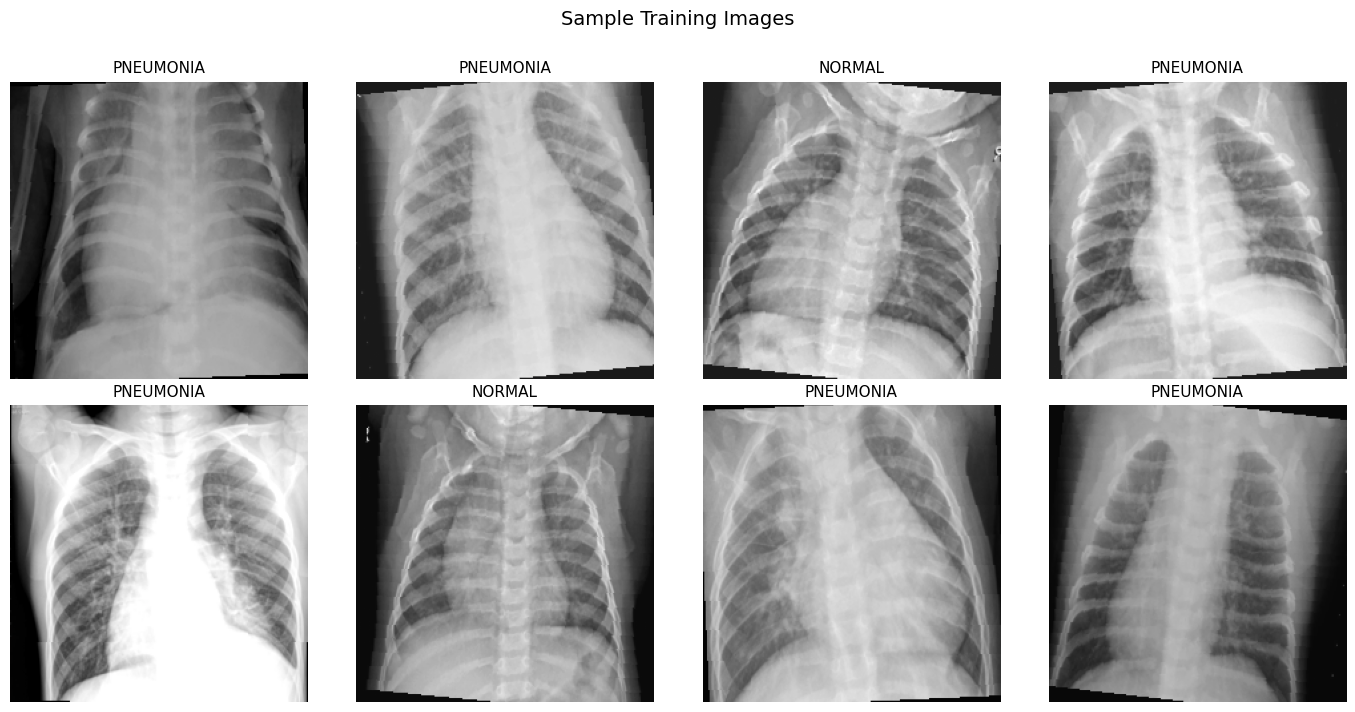

In [ ]:
import matplotlib.pyplot as plt

def denormalize(tensor):
    mean = torch.tensor(MEAN).view(3,1,1)
    std  = torch.tensor(STD).view(3,1,1)
    return (tensor * std + mean).clamp(0, 1)

imgs, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    img = denormalize(imgs[i]).permute(1, 2, 0).numpy()
    ax.imshow(img, cmap='gray')
    ax.set_title(train_dataset.classes[labels[i]], fontsize=11)
    ax.axis('off')
plt.suptitle('Sample Training Images', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'sample_images.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import torch.nn as nn
import torchvision.models as models

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_CLASSES = 2

def build_model(freeze_base=True):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    if freeze_base:
        for param in model.parameters():
            param.requires_grad = False
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, NUM_CLASSES)
    )
    return model.to(DEVICE)

model = build_model(freeze_base=True)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,}')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 64.1MB/s]


Trainable params: 525,058 / 24,033,090


In [ ]:
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels, all_probs

print('Training utilities ready.')

Training utilities ready.


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
scheduler = CosineAnnealingLR(optimizer, T_max=5)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0

print('Phase 1: Training classifier head only...')
for epoch in range(5):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc, _, _, _ = evaluate(model, val_loader, criterion)
    scheduler.step()
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(val_acc)
    print(f'Epoch {epoch+1}/5 | Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), os.path.join(SAVE_DIR, 'best_model.pth'))
        print('  ✓ Saved best model')

print(f'\nPhase 1 complete. Best val acc: {best_val_acc:.4f}')

Phase 1: Training classifier head only...
Epoch 1/5 | Train Loss: 0.3337 Acc: 0.8520 | Val Loss: 0.2856 Acc: 0.8750
  ✓ Saved best model
Epoch 2/5 | Train Loss: 0.2516 Acc: 0.8957 | Val Loss: 0.2420 Acc: 0.9375
  ✓ Saved best model
Epoch 3/5 | Train Loss: 0.2092 Acc: 0.9204 | Val Loss: 0.2553 Acc: 0.9375
Epoch 4/5 | Train Loss: 0.1908 Acc: 0.9245 | Val Loss: 0.3550 Acc: 0.7500
Epoch 5/5 | Train Loss: 0.2096 Acc: 0.9130 | Val Loss: 0.2791 Acc: 0.8125

Phase 1 complete. Best val acc: 0.9375


In [ ]:
for param in model.parameters():
    param.requires_grad = True

optimizer = Adam([
    {'params': model.fc.parameters(),   'lr': 1e-3},
    {'params': [p for n, p in model.named_parameters() if 'fc' not in n], 'lr': 1e-4}
])
scheduler = CosineAnnealingLR(optimizer, T_max=10)

PATIENCE = 4
no_improve = 0

print('Phase 2: Fine-tuning all layers...')
for epoch in range(10):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc, _, _, _ = evaluate(model, val_loader, criterion)
    scheduler.step()
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(val_acc)
    print(f'Epoch {epoch+1}/10 | Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        no_improve = 0
        torch.save(model.state_dict(), os.path.join(SAVE_DIR, 'best_model.pth'))
        print('  ✓ Saved best model')
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f'  Early stopping at epoch {epoch+1}')
            break

print(f'\nPhase 2 complete. Best val acc: {best_val_acc:.4f}')

Phase 2: Fine-tuning all layers...
Epoch 1/10 | Train Loss: 0.1358 Acc: 0.9507 | Val Loss: 0.0876 Acc: 1.0000
  ✓ Saved best model
Epoch 2/10 | Train Loss: 0.0775 Acc: 0.9722 | Val Loss: 0.1166 Acc: 0.9375
Epoch 3/10 | Train Loss: 0.0611 Acc: 0.9762 | Val Loss: 0.2017 Acc: 0.8750
Epoch 4/10 | Train Loss: 0.0540 Acc: 0.9812 | Val Loss: 0.0518 Acc: 1.0000
Epoch 5/10 | Train Loss: 0.0343 Acc: 0.9870 | Val Loss: 0.0545 Acc: 1.0000
  Early stopping at epoch 5

Phase 2 complete. Best val acc: 1.0000


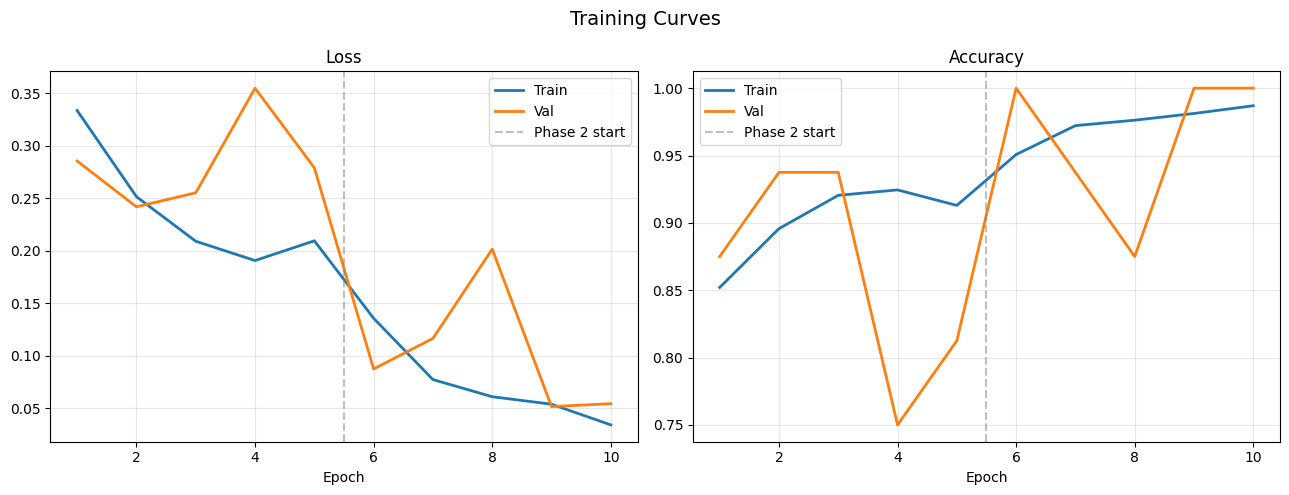

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
epochs = range(1, len(history['train_loss']) + 1)

ax1.plot(epochs, history['train_loss'], label='Train', linewidth=2)
ax1.plot(epochs, history['val_loss'],   label='Val',   linewidth=2)
ax1.axvline(x=5.5, color='gray', linestyle='--', alpha=0.5, label='Phase 2 start')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs, history['train_acc'], label='Train', linewidth=2)
ax2.plot(epochs, history['val_acc'],   label='Val',   linewidth=2)
ax2.axvline(x=5.5, color='gray', linestyle='--', alpha=0.5, label='Phase 2 start')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('Training Curves', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

=== TEST SET RESULTS ===
Accuracy : 0.9006
F1 Score : 0.9015
ROC-AUC  : 0.9614

              precision    recall  f1-score   support

      NORMAL       0.83      0.92      0.87       234
   PNEUMONIA       0.95      0.89      0.92       390

    accuracy                           0.90       624
   macro avg       0.89      0.91      0.90       624
weighted avg       0.91      0.90      0.90       624



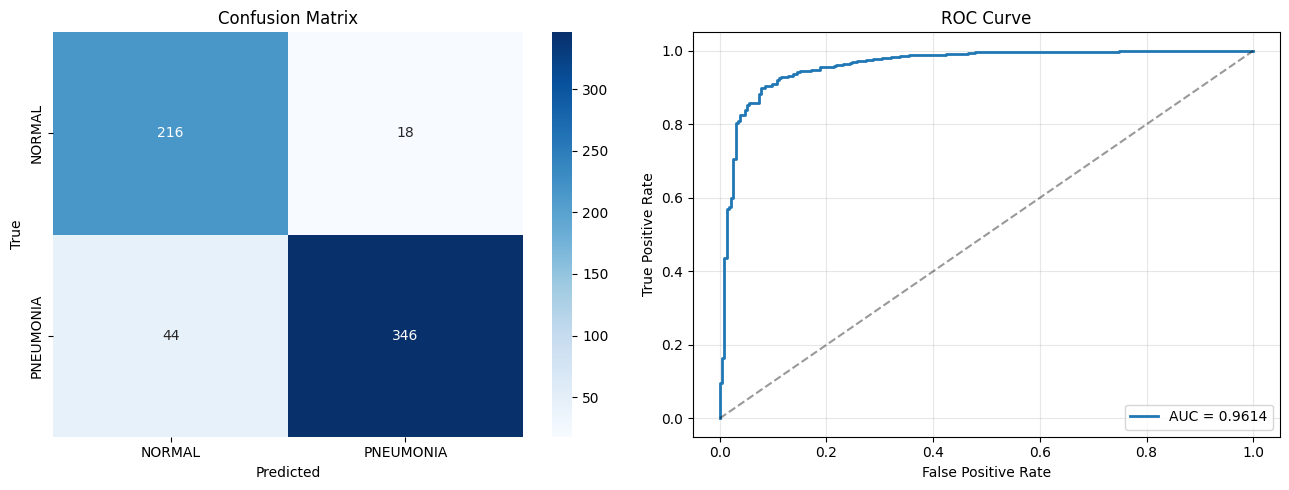

In [ ]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, f1_score)
import seaborn as sns

model.load_state_dict(torch.load(os.path.join(SAVE_DIR, 'best_model.pth')))
_, test_acc, preds, labels, probs = evaluate(model, test_loader, criterion)

roc_auc = roc_auc_score(labels, probs)
f1 = f1_score(labels, preds, average='weighted')

print('=== TEST SET RESULTS ===')
print(f'Accuracy : {test_acc:.4f}')
print(f'F1 Score : {f1:.4f}')
print(f'ROC-AUC  : {roc_auc:.4f}')
print()
print(classification_report(labels, preds, target_names=test_dataset.classes))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(labels, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_dataset.classes,
            yticklabels=test_dataset.classes, ax=ax1)
ax1.set_title('Confusion Matrix'); ax1.set_ylabel('True'); ax1.set_xlabel('Predicted')

fpr, tpr, _ = roc_curve(labels, probs)
ax2.plot(fpr, tpr, linewidth=2, label=f'AUC = {roc_auc:.4f}')
ax2.plot([0,1], [0,1], 'k--', alpha=0.4)
ax2.set_xlabel('False Positive Rate'); ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve'); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'evaluation.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import cv2

target_layers = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

def generate_gradcam(image_tensor, label=None):
    """Generate Grad-CAM heatmap for a single image tensor."""
    targets = [ClassifierOutputTarget(label)] if label is not None else None
    grayscale_cam = cam(input_tensor=image_tensor.unsqueeze(0).to(DEVICE),
                        targets=targets)
    return grayscale_cam[0]

print('Grad-CAM initialized on layer4[-1]')

Grad-CAM initialized on layer4[-1]


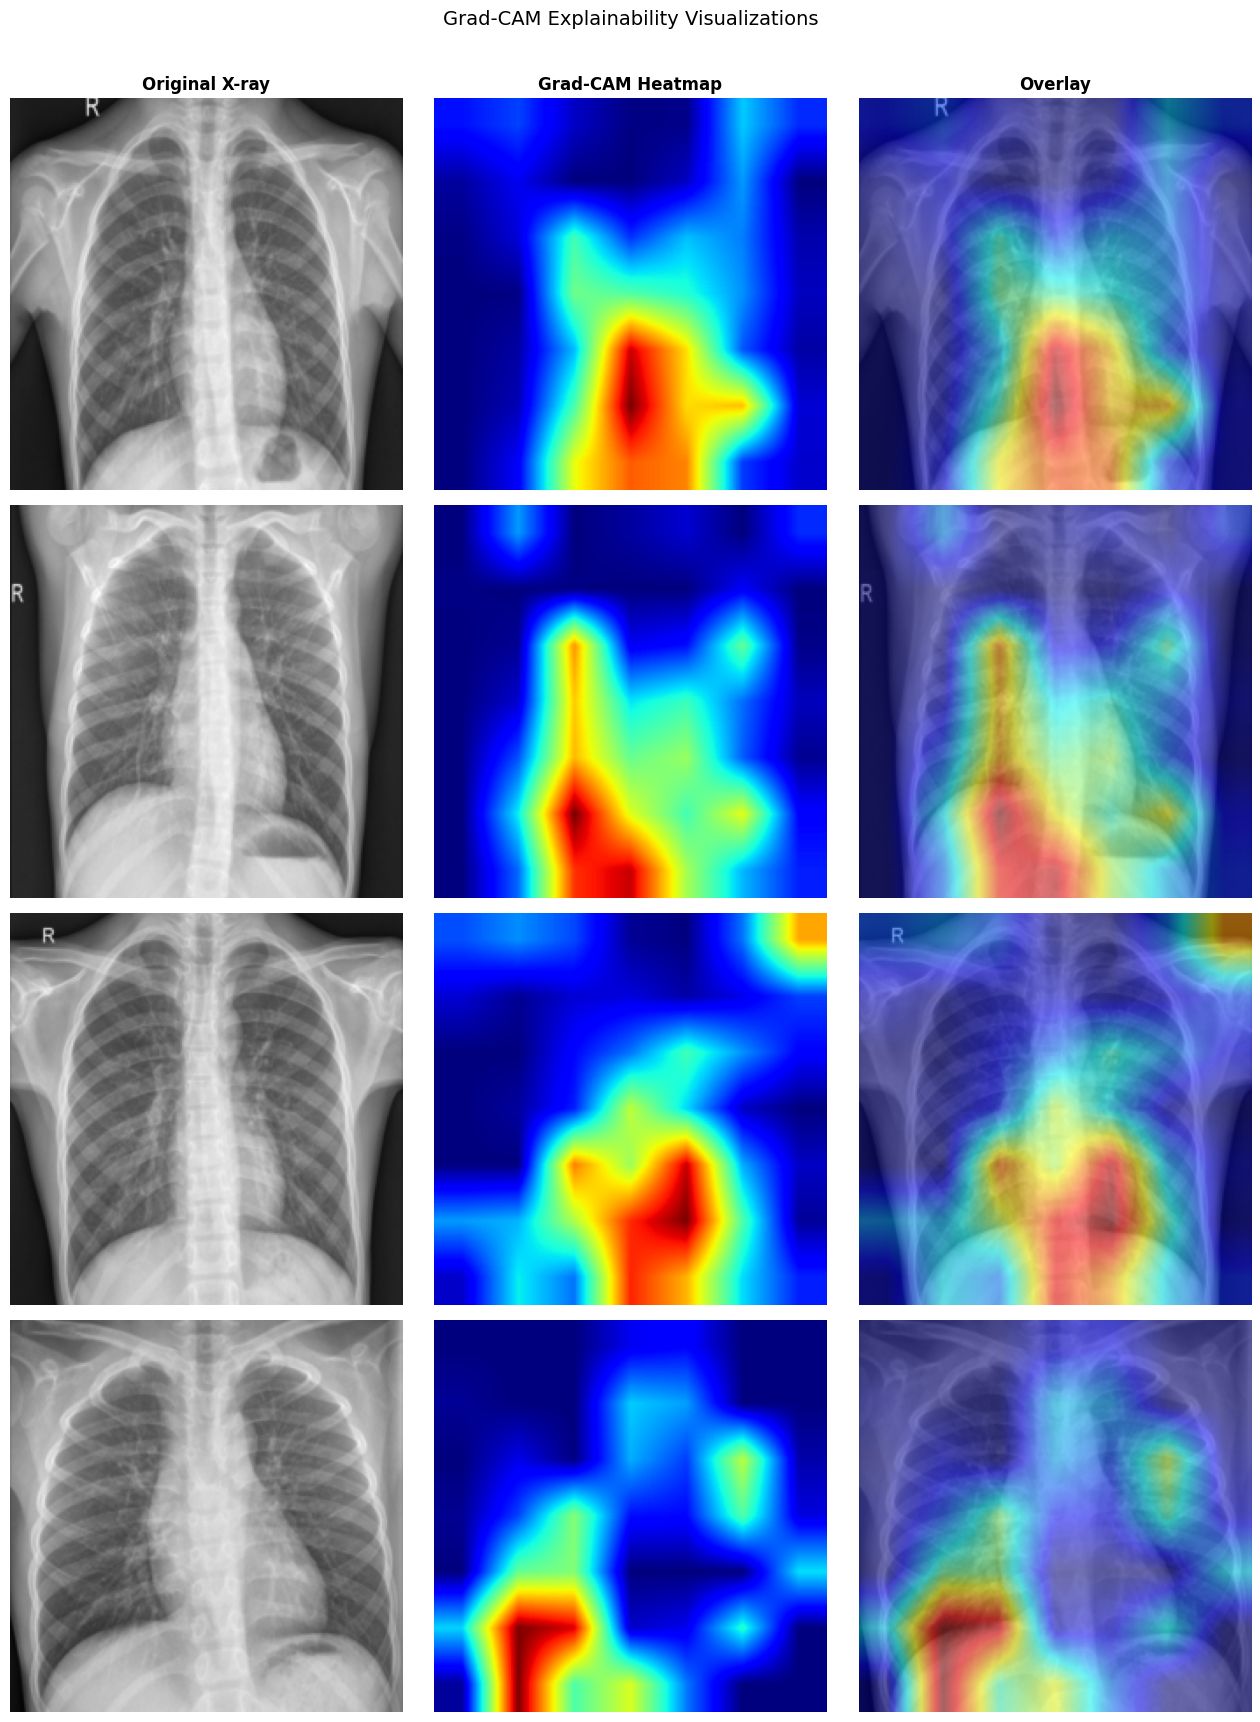

Saved to /content/drive/MyDrive/pulmonary_model


In [ ]:
model.eval()
test_imgs, test_labels = next(iter(test_loader))

fig, axes = plt.subplots(4, 3, figsize=(13, 17))
col_titles = ['Original X-ray', 'Grad-CAM Heatmap', 'Overlay']
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=12, fontweight='bold')

for i in range(4):
    img_tensor = test_imgs[i]
    true_label = test_labels[i].item()

    with torch.no_grad():
        pred = model(img_tensor.unsqueeze(0).to(DEVICE)).argmax(1).item()

    # Denormalize for display
    img_np = denormalize(img_tensor).permute(1, 2, 0).numpy()

    # Generate CAM
    grayscale_cam = generate_gradcam(img_tensor, label=pred)
    overlay = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    status = 'Correct' if pred == true_label else 'Wrong'
    row_label = (f'True: {test_dataset.classes[true_label]}\n'
                 f'Pred: {test_dataset.classes[pred]} ({status})')

    axes[i][0].imshow(img_np, cmap='gray'); axes[i][0].set_ylabel(row_label, fontsize=9)
    axes[i][1].imshow(grayscale_cam, cmap='jet')
    axes[i][2].imshow(overlay)
    for ax in axes[i]: ax.axis('off')

plt.suptitle('Grad-CAM Explainability Visualizations', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'gradcam_results.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved to', SAVE_DIR)

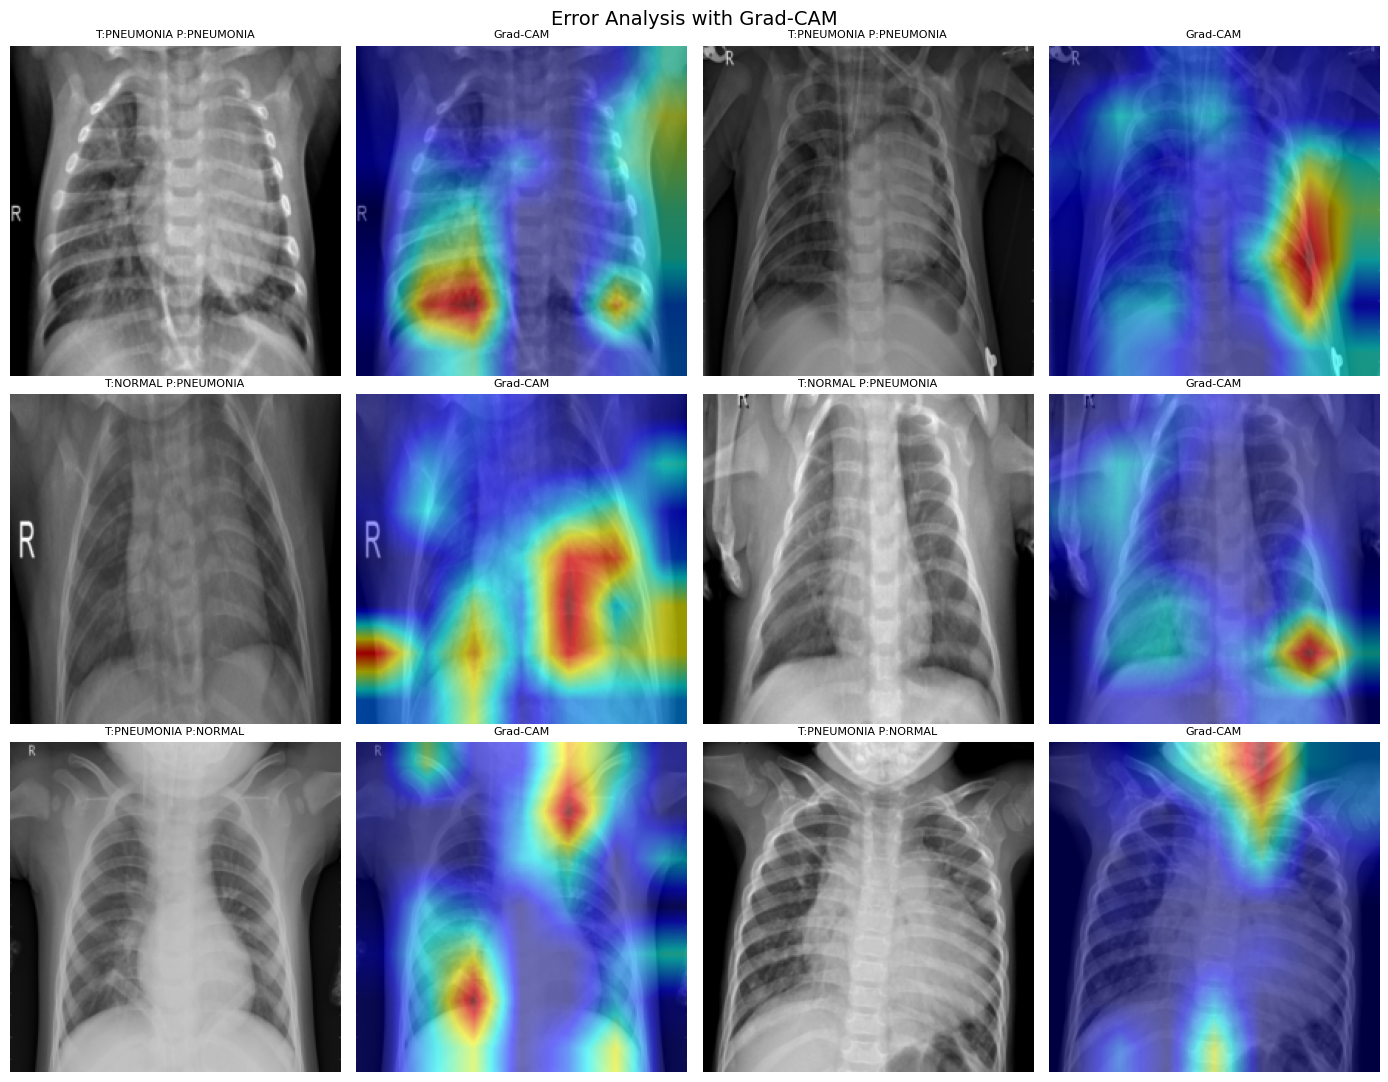

In [ ]:
model.eval()
tp_imgs, fp_imgs, fn_imgs = [], [], []

for imgs, lbls in test_loader:
    with torch.no_grad():
        preds = model(imgs.to(DEVICE)).argmax(1).cpu()
    for img, lbl, pred in zip(imgs, lbls, preds):
        lbl, pred = lbl.item(), pred.item()
        if lbl == 1 and pred == 1 and len(tp_imgs) < 2: tp_imgs.append((img, lbl, pred))
        if lbl == 0 and pred == 1 and len(fp_imgs) < 2: fp_imgs.append((img, lbl, pred))
        if lbl == 1 and pred == 0 and len(fn_imgs) < 2: fn_imgs.append((img, lbl, pred))
    if len(tp_imgs) == 2 and len(fp_imgs) == 2 and len(fn_imgs) == 2: break

groups = [('True Positives (Correct Pneumonia)', tp_imgs),
          ('False Positives (Normal → Pneumonia)', fp_imgs),
          ('False Negatives (Pneumonia → Normal)', fn_imgs)]

fig, axes = plt.subplots(3, 4, figsize=(14, 11))
for row, (title, group) in enumerate(groups):
    axes[row][0].set_ylabel(title, fontsize=9, fontweight='bold')
    for col_offset, (img, lbl, pred) in enumerate(group):
        img_np = denormalize(img).permute(1,2,0).numpy()
        cam_map = generate_gradcam(img, label=pred)
        overlay = show_cam_on_image(img_np, cam_map, use_rgb=True)
        axes[row][col_offset*2].imshow(img_np, cmap='gray')
        axes[row][col_offset*2].set_title(f'T:{test_dataset.classes[lbl]} P:{test_dataset.classes[pred]}', fontsize=8)
        axes[row][col_offset*2+1].imshow(overlay)
        axes[row][col_offset*2+1].set_title('Grad-CAM', fontsize=8)
    for ax in axes[row]: ax.axis('off')

plt.suptitle('Error Analysis with Grad-CAM', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'error_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:

import json

model_info = {
    'architecture': 'ResNet-50',
    'num_classes': NUM_CLASSES,
    'classes': test_dataset.classes,
    'img_size': IMG_SIZE,
    'mean': MEAN,
    'std': STD,
    'test_accuracy': round(test_acc, 4),
    'roc_auc': round(roc_auc, 4),
    'f1_score': round(f1, 4)
}

with open(os.path.join(SAVE_DIR, 'model_info.json'), 'w') as f:
    json.dump(model_info, f, indent=2)


model.eval()
scripted = torch.jit.trace(model, torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE))
scripted.save(os.path.join(SAVE_DIR, 'model_scripted.pt'))

print('Saved to Google Drive:')
for f in os.listdir(SAVE_DIR):
    size = os.path.getsize(os.path.join(SAVE_DIR, f)) / 1e6
    print(f'  {f} ({size:.1f} MB)')
print('\nModel info:')
print(json.dumps(model_info, indent=2))

Saved to Google Drive:
  sample_images.png (0.8 MB)
  best_model.pth (96.5 MB)
  training_curves.png (0.1 MB)
  evaluation.png (0.1 MB)
  gradcam_results.png (2.4 MB)
  error_analysis.png (2.0 MB)
  model_info.json (0.0 MB)
  model_scripted.pt (96.7 MB)

Model info:
{
  "architecture": "ResNet-50",
  "num_classes": 2,
  "classes": [
    "NORMAL",
    "PNEUMONIA"
  ],
  "img_size": 224,
  "mean": [
    0.485,
    0.456,
    0.406
  ],
  "std": [
    0.229,
    0.224,
    0.225
  ],
  "test_accuracy": 0.9006,
  "roc_auc": 0.9614,
  "f1_score": 0.9015
}


In [ ]:
!pip install -q gradio huggingface_hub

HF_TOKEN = "your_hf_token_here"

import gradio as gr
from PIL import Image

def predict(pil_image):
    transform = val_transform
    img_tensor = transform(pil_image.convert('RGB')).unsqueeze(0).to(DEVICE)
    model.eval()
    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.softmax(outputs, dim=1)[0]
    pred_idx = probs.argmax().item()
    pred_class = test_dataset.classes[pred_idx]
    confidence = probs[pred_idx].item()

    img_np = denormalize(img_tensor.squeeze(0).cpu()).permute(1,2,0).numpy()
    cam_map = generate_gradcam(img_tensor.squeeze(0).cpu(), label=pred_idx)
    overlay = show_cam_on_image(img_np, cam_map, use_rgb=True)
    overlay_pil = Image.fromarray(overlay)

    result = {cls: float(probs[i]) for i, cls in enumerate(test_dataset.classes)}
    label = f'{pred_class} ({confidence:.1%} confidence)'
    return overlay_pil, result, label

demo = gr.Interface(
    fn=predict,
    inputs=gr.Image(type='pil', label='Upload Chest X-Ray'),
    outputs=[
        gr.Image(label='Grad-CAM Overlay'),
        gr.Label(label='Class Probabilities'),
        gr.Textbox(label='Prediction')
    ],
    title='Pulmonary Disease Detector',
    description='Upload a chest X-ray to detect pneumonia using ResNet-50 with Grad-CAM explainability.',
    examples=[]
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3cdcb996b21031095c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
